# Plotting cell type markers in vivo

In [85]:
here::i_am("revisions/03_cellannotation/02_invivo_comparison.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(ArchR))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

set.seed(1234)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [119]:
args = list()

io$multiome_atlas =  "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome"
args$metadataRNA_atlas <- file.path(io$multiome_atlas,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$metadataATAC_atlas <- file.path(io$multiome_atlas, '/results/atac/archR/qc/sample_metadata_after_qc.txt.gz')
args$sce_atlas <-file.path(io$multiome_atlas,"data/processed/rna/SingleCellExperiment.rds")


# outdir
args$outdir = file.path(io$basedir, 'results/revisions/03_cellannotation/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [120]:
metadata_atlas <- fread(args$metadataRNA_atlas) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE] %>%
    merge(.,fread(args$metadataATAC_atlas)[,c('cell', 'pass_atacQC')], by='cell') %>%
    .[pass_atacQC==TRUE]

In [121]:
sce <- load_SingleCellExperiment(
  file = args$sce_atlas, 
  normalise = TRUE, 
  cells = metadata_atlas$cell, 
  remove_non_expressed_genes = TRUE
)

colData(sce) <- metadata_atlas %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce),] %>% DataFrame()

sce_atlas = sce

In [122]:
head(sce_atlas$celltype)

[1] "Mixed_mesoderm"      "Primitive_Streak"    "Somitic_mesoderm"   
[4] "Gut"                 "Caudal_epiblast"     "Blood_progenitors_1"

In [123]:
features = c('Gjb3', 'Ifitm3', 'Fgf8',  # PGC
             'Nanog', 'Zic3', 'Pou5f1', 'T', #PS
             'Eomes', 'Mixl1', 'Mesp1', 'Lhx1','Pdgfra',  #Early Mes 1
             'Etv2', 'Kdr', 'Fgf10', # HE Pre
             'Gata2', 'Fli1', 'Flt1', 'Hapln1', # HE
             'Cdh5', 'Calcrl', 'Tek', # Endo
             'Runx1', 'Hbb-bh1', 'Ikzf1', # Blood P
             'Rspo3', 'Igfbp3', 'Bmper', # Early Mes 2 --> search for other markers?
             'Dlk1', 'Hand1', 'Tgfb2',# Post Mes
             'Podxl', 'Foxf1', # Mesenchyme
             'Spin2c',
             'Hoxa11', 'Tbx4', 'Pitx1' # Allantois
             )

In [124]:
# Violin plots instead of dotplot heatmap
meta_tmp = metadata_atlas %>% 
    .[,.(celltype)]

expr = mclapply(features, function(x){
    tmp = cbind(meta_tmp, 
                data.table(gene = x,
                           expression = as.numeric(logcounts(sce_atlas[x,]))
                          )
               )
    return(tmp)
    
}, mc.cores = 32) %>% rbindlist() %>% 
    .[, expression_minmax := minmax.normalisation(expression), by = 'gene']

In [125]:
opts$celltype_order = c(
                        'Blood_progenitors_2',
                        'Endothelium',
                        'Haematoendothelial_progenitors',
                        'Nascent_mesoderm',
                        'Primitive_Streak',
                        'Mixed_mesoderm',
                        'ExE_mesoderm',
                        'Mesenchyme',
                        'Allantois',
                        'PGC'
                        )

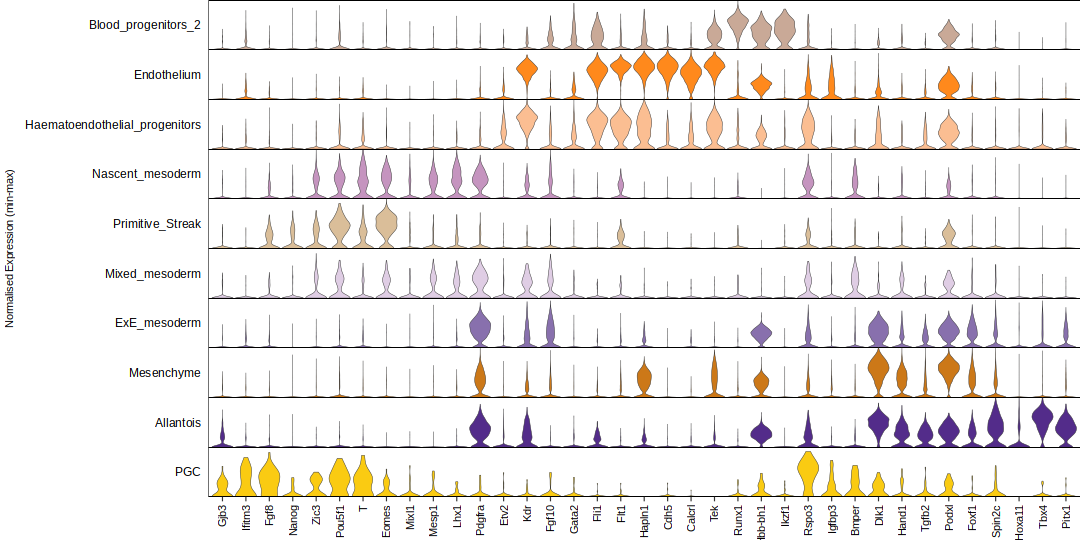

In [130]:
expr_plot = expr %>%
    .[, gene := factor(gene, levels = features)] %>%
    .[celltype %in% opts$celltype_order] %>%
    .[, celltype := factor(celltype, levels = opts$celltype_order)] %>%
    .[, expression_minmax_pruned := ifelse(expression_minmax > quantile(expression_minmax, 0.95), quantile(expression_minmax, 0.95),expression_minmax),
          by = c('celltype', 'gene')]
                                        
options(repr.plot.width=9, repr.plot.height=4.5)

p2 = ggplot(expr_plot, aes(gene, expression_minmax, fill = celltype)) + 
    geom_violin(scale = 'width', linewidth = 0.1) +
    scale_fill_manual(values = opts$celltype.colors) + 
    scale_y_continuous(expand = c(0,0)) + 
    facet_grid(celltype~., switch = 'y') +
    ylab('Normalised Expression (min-max)') + 
    theme_bw() + 
    theme(axis.text.x = element_text(color = 'black',
                                     angle = 90, 
                                     hjust = 1,
                                     vjust = 0.5, size=6),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank(),
            axis.title.x = element_blank(),
            strip.background = element_blank(),
            strip.text.y.left = element_text(angle = 0, hjust = 1, color= 'black', size=7),
            panel.spacing = unit(0,'lines'),
            panel.grid = element_blank(),
            legend.position = 'none',
            axis.title.y = element_text(size = 6, vjust = -2),
            panel.background = element_rect(color = "white", fill = NA, linewidth = 0.01),
            panel.border = element_rect(color = "black", fill = NA, linewidth = 0.2),
            plot.margin = margin(0,0,0,0),
            axis.line.y = element_blank(),
            axis.line.x = element_line(color = 'black', linewidth = 0.1),
            axis.ticks = element_line(linewidth=0.25),
)
p2

In [129]:
ggsave(file.path(args$outdir, 'multiome_atlas_celltype_marker_genes_violins.pdf'), 
       plot = p2,
       width = 120, 
       height = 55, 
       units = "mm")

In [10]:
ArchRProject = ArchR::loadArchRProject(file.path(io$multiome_atlas, 'data/processed/atac/archR'))

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [11]:
ArchRProject


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/atac/archR 
samples(11): E7.5_rep1 E7.5_rep2 ... E8.5_CRISPR_T_KO E8.5_CRISPR_T_WT
sampleColData names(1): ArrowFiles
cellColData names(35): Sample TSSEnrichment ... ReadsInPeaks FRIP
numberOfCells(1): 89137
medianTSS(1): 16.382
medianFrags(1): 22077

In [12]:
ArchRProject[metadata_atlas$cell]


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/atac/archR 
samples(11): E7.5_rep1 E7.5_rep2 ... E8.5_CRISPR_T_KO E8.5_CRISPR_T_WT
sampleColData names(1): ArrowFiles
cellColData names(35): Sample TSSEnrichment ... ReadsInPeaks FRIP
numberOfCells(1): 57729
medianTSS(1): 16.778
medianFrags(1): 30014

In [13]:
ArchRProject = ArchRProject[metadata_atlas$cell]

In [62]:
chip_chromvar = readRDS('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/archR/chromvar_chip/pseudobulk/chromVAR_chip_CISBP_archr.rds')

In [96]:
features = c('TFAP2C', # Add TFAP2C once updated chromvar is done!
             'NANOG', 'ZIC3','POU5F1',
             'T', 'EOMES', 'MIXL1',  
             'MESP2', 'LHX1',  
             'ETV2', 'GATA2', 
             'SOX7', 'ERG', 'SOX18', 
             'RUNX1', 'TAL1', 'GATA1', 
             'TCF7L1', 
             'HAND1', 'GATA6', 'GATA5', 'FOXF2',
             'CDX4', 'HOXA11', 'TBX4',  'PITX1'
             )
features = features[features %in% rownames(chip_chromvar)]

opts$celltype_order = c(
                        'Blood_progenitors_2',
                        'Endothelium',
                        'Haematoendothelial_progenitors',
                        'Nascent_mesoderm',
                        'Primitive_Streak',
                        'Mixed_mesoderm',
                        'ExE_mesoderm',
                        'Mesenchyme',
                        'Allantois',
                        'PGC'
                        )

In [109]:
tmp = lapply(opts$celltype_order, function(x){
    #print(x)
    tmp = as.data.table(assay(chip_chromvar, 'z')[features,x], keep.rownames = T) %>% 
        setnames(c('feature', 'z_score')) %>%
        .[,celltype := x]
    return(tmp)
    }
) %>% rbindlist() %>% 
    .[,minmax_z_score := minmax.normalisation(z_score), by='feature']

head(tmp)

feature,z_score,celltype,minmax_z_score
<chr>,<dbl>,<chr>,<dbl>
TFAP2C,-40.29980,Blood_progenitors_2,0.01534079
NANOG,-27.19324,Blood_progenitors_2,0.09225716
ZIC3,-35.19037,Blood_progenitors_2,0.04660827
POU5F1,-47.28336,Blood_progenitors_2,0.05196987
T,-47.74606,Blood_progenitors_2,0.00000000
EOMES,-50.33303,Blood_progenitors_2,0.00000000


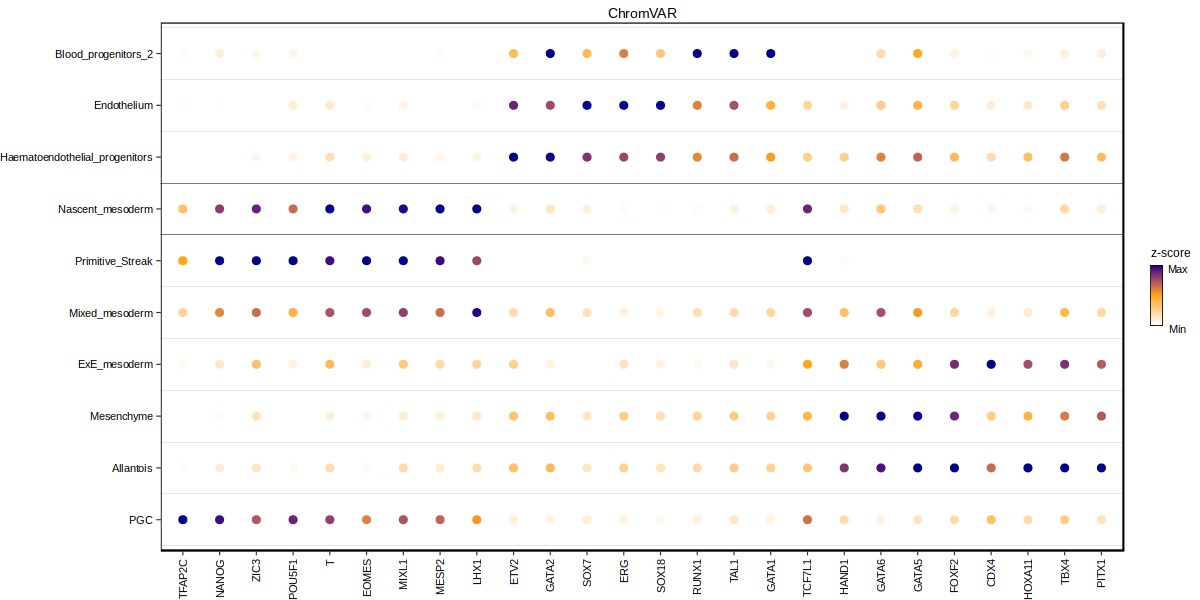

In [115]:
options(repr.plot.width=10, repr.plot.height=5)
p = ggplot(tmp, aes(feature, celltype, color = minmax_z_score)) + 
    scale_y_discrete(limits = rev(opts$celltype_order)) +
    scale_x_discrete(limits = features) +
    geom_point() +
    scale_color_gradientn(colors = c('white', 'orange', 'darkblue'), name = 'z-score', breaks = c(0,1), labels = c('Min', 'Max')) +
    guides(colour = guide_colourbar(
         barwidth = 0.5, barheight = 2.5,
        frame.colour = "black", 
        ticks.colour = "black"
    )) + 
    scale_size(range = c(-0.3, 1.5)) + 
    geom_hline(yintercept=seq(.5, 20, 1), alpha=0.2, linewidth = 0.1) + 
    geom_hline(yintercept=c(6.5, 7.5), alpha=1, linewidth = 0.1) + 
    ggtitle('ChromVAR') +

    theme(text=element_text(size=6), 
                         axis.text.x=element_text(angle=90,hjust=1,vjust=0.5, size=6, color = 'black'), 
                         axis.text.y=element_text(hjust=1, size = 6, color = 'black'),
                         axis.title = element_blank(),
                         panel.border = element_rect(color='black', linewidth=0.5, fill = NA),
                         panel.background = element_blank(),
                         plot.margin = margin(0,0,0,0),
                         plot.title = element_text(size=8, hjust=0.5, vjust=-1.5, face='plain'),
                         axis.line = element_blank(),
                         axis.ticks=element_line(linewidth=0.25),
                         legend.title = element_text(size = 7, hjust=0, vjust = 1),
                         legend.text = element_text(size = 6, hjust=0.5, vjust = 1),
                         legend.position = 'right',
                        # plot.margin = margin(t = 0, r = 0, b = 0, l = 0) # Adjust margins as needed
)
p

In [116]:
args$outdir

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/revisions/03_cellannotation/"

In [128]:
ggsave(file.path(args$outdir, 'multiome_atlas_celltype_chromvar.pdf'), 
       plot = p + theme(legend.position = 'none'),
       width = 105, 
       height = 55, 
       units = "mm")

In [ ]:
getAvailableMatrices(ArchRProject)

[1] "GeneScoreMatrix_TSS"    "GeneScoreMatrix_distal" "Genes"                 
[4] "PeakMatrix"             "TileMatrix"             "vitroPeakMatrix"

In [ ]:
# io$multiome = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/'
# cisbp_silico_chip = readRDS(file.path(io$multiome, 'vitro_peaks_silicoChIP_cisbp.rds'))

In [49]:
cisbp_silico_chip = readRDS('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna_atac/virtual_chipseq/metacells/CISBP/motifmatchr_virtual_chip.rds')

In [50]:
assay(cisbp_silico_chip, 'matches') = assay(cisbp_silico_chip, 'VirtualChipScores') > 0.15

In [51]:
assay(cisbp_silico_chip, 'motifScores') = NULL
assay(cisbp_silico_chip, 'motifMatches') = NULL
assay(cisbp_silico_chip, 'motifCounts') = NULL
assay(cisbp_silico_chip, 'VirtualChipScores') = NULL

In [52]:
# Keep only motifs with more than 40 peaks 
tmp = colSums(assay(cisbp_silico_chip, 'matches') )
keep = names(tmp[tmp > 0])
cisbp_silico_chip = cisbp_silico_chip[,keep]

In [53]:
cisbp_silico_chip

class: RangedSummarizedExperiment 
dim: 192251 546 
metadata(0):
assays(1): matches
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(13): score replicateScoreQuantile ... idx N
colnames(546): AHR AHRR ... ZKSCAN3 ZSCAN10
colData names(1): name

In [54]:
lapply(c('TFAP2C', # Add TFAP2C once updated chromvar is done!
             'NANOG', 'ZIC3','POU5F1',
             'T', 'EOMES', 'MIXL1',  
             'MESP2', 'LHX1',  
             'ETV2', 'GATA2', 
             'SOX7', 'ERG', 'SOX18', 
             'RUNX1', 'TAL1', 'GATA1', 
             'TCF7L1', 
             'HAND1', 'GATA6', 'GATA5', 'FOXF2',
             'CDX4', 'HOXA11', 'TBX4',  'PITX1'
             ), function(x){
    paste0(x, ':', grep(x, colnames(cisbp_silico_chip)))
})

[[1]]
[1] "TFAP2C:503"

[[2]]
[1] "NANOG:308"

[[3]]
[1] "ZIC3:541"

[[4]]
[1] "POU5F1:390"

[[5]]
  [1] "T:13"  "T:14"  "T:15"  "T:16"  "T:20"  "T:21"  "T:22"  "T:23"  "T:24" 
 [10] "T:25"  "T:26"  "T:30"  "T:31"  "T:39"  "T:57"  "T:61"  "T:66"  "T:67" 
 [19] "T:68"  "T:69"  "T:70"  "T:100" "T:101" "T:102" "T:103" "T:104" "T:105"
 [28] "T:106" "T:147" "T:148" "T:149" "T:150" "T:151" "T:152" "T:181" "T:298"
 [37] "T:310" "T:311" "T:312" "T:313" "T:357" "T:358" "T:360" "T:361" "T:363"
 [46] "T:378" "T:379" "T:409" "T:469" "T:470" "T:471" "T:472" "T:473" "T:474"
 [55] "T:475" "T:476" "T:477" "T:478" "T:479" "T:480" "T:481" "T:482" "T:483"
 [64] "T:484" "T:485" "T:486" "T:487" "T:488" "T:489" "T:490" "T:491" "T:492"
 [73] "T:493" "T:494" "T:495" "T:496" "T:497" "T:498" "T:499" "T:500" "T:501"
 [82] "T:502" "T:503" "T:504" "T:505" "T:506" "T:507" "T:508" "T:509" "T:510"
 [91] "T:511" "T:512" "T:513" "T:514" "T:515" "T:516" "T:517" "T:518" "T:519"
[100] "T:524" "T:525" "T:529" "T:530" "T:531" "T:532"

[[6]]
[1] "EOMES:90"

[[7]]
[1] "MIXL1:292"

[[8]]
[1] "MESP2:290"

[[9]]
[1] "LHX1:261"

[[10]]
[1] "ETV2:103"

[[11]]
[1] "GATA2:148"

[[12]]
[1] "SOX7:457"

[[13]]
[1] "ERG:94"

[[14]]
[1] "SOX18:450"

[[15]]
[1] "RUNX1:421"

[[16]]
[1] "TAL1:476"

[[17]]
[1] "GATA1:147"

[[18]]
[1] "TCF7L1:493"

[[19]]
[1] "HAND1:165"

[[20]]
[1] "GATA6:152"

[[21]]
[1] "GATA5:151"

[[22]]
[1] "FOXF2:127"

[[23]]
[1] "CDX4:44"

[[24]]
[1] "HOXA11:191"

[[25]]
[1] "TBX4:484"

[[26]]
[1] "PITX1:378"

In [56]:
addArchRThreads(36)
ArchRProject <- addDeviationsMatrix(
      ArchRProj = ArchRProject, 
      matches = cisbp_silico_chip,
      matrixName = 'silicoChIP_CISBP_v2',
      force = TRUE
    )

Setting default number of Parallel threads to 36.

Identifying Background Peaks!

ArchR logging to : ArchRLogs/ArchR-addDeviationsMatrix-341a24fa43359-Date-2024-11-20_Time-10-46-29.log
If there is an issue, please report to github with logFile!



class: RangedSummarizedExperiment 
dim: 192251 546 
metadata(0):
assays(1): matches
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(13): score replicateScoreQuantile ... idx N
colnames(546): AHR AHRR ... ZKSCAN3 ZSCAN10
colData names(1): name


2024-11-20 10:46:34 : Batch Execution w/ safelapply!, 0 mins elapsed.



In [19]:
io$multiome_atlas

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome"

### Original scRNA-seq atlas

In [2]:
metadata_atlas <- fread(io$rna.atlas.metadata) %>%
  .[doublet==FALSE & doublet==FALSE]

In [3]:
sce <- load_SingleCellExperiment(
  file = io$rna.atlas.sce, 
  normalise = TRUE, 
  cells = metadata_atlas$cell, 
  remove_non_expressed_genes = TRUE
)

colData(sce) <- metadata_atlas %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce),] %>% DataFrame()

sce_atlas = sce

In [4]:
sce_atlas

class: SingleCellExperiment 
dim: 19476 116312 
metadata(1): log.exprs.offset
assays(2): counts logcounts
rownames(19476): ENSMUSG00000051951 ENSMUSG00000025900 ...
  ENSMUSG00000063897 ENSMUSG00000095742
rowData names(0):
colnames(116312): cell_1 cell_10 ... cell_99998 cell_99999
colData names(11): barcode sample ... nFeature_RNA nCount_RNA
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [5]:
gene_metadata = fread(io$gene_metadata)

In [6]:
head(gene_metadata)

chr,start,end,strand,ens_id,description,symbol
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chr1,3073253,3074322,+,ENSMUSG00000102693,RIKEN cDNA 4933401J01 gene [Source:MGI Symbol;Acc:MGI:1918292],4933401J01Rik
chr1,3102016,3102125,+,ENSMUSG00000064842,"predicted gene, 26206 [Source:MGI Symbol;Acc:MGI:5455983]",Gm26206
chr1,3205901,3671498,-,ENSMUSG00000051951,X-linked Kx blood group related 4 [Source:MGI Symbol;Acc:MGI:3528744],Xkr4
chr1,3252757,3253236,+,ENSMUSG00000102851,"predicted gene, 18956 [Source:MGI Symbol;Acc:MGI:5011141]",Gm18956
chr1,3365731,3368549,-,ENSMUSG00000103377,"predicted gene, 37180 [Source:MGI Symbol;Acc:MGI:5610408]",Gm37180
chr1,3375556,3377788,-,ENSMUSG00000104017,"predicted gene, 37363 [Source:MGI Symbol;Acc:MGI:5610591]",Gm37363


In [8]:
class(gene_metadata[match(rownames(sce_atlas), ens_id), symbol])

[1] "character"

In [9]:
head(rownames(sce_atlas) )

[1] "ENSMUSG00000051951" "ENSMUSG00000025900" "ENSMUSG00000025902"
[4] "ENSMUSG00000033845" "ENSMUSG00000025903" "ENSMUSG00000104217"

In [10]:
length(rownames(sce_atlas) )

[1] 19476

In [11]:
rownames(sce_atlas) = gene_metadata[match(rownames(sce_atlas), ens_id), symbol]

In [7]:
head(rownames(sce_atlas))

[1] "Xkr4"    "Rp1"     "Sox17"   "Mrpl15"  "Lypla1"  "Gm37988"

In [12]:
features = c('Gjb3', 'Ifitm3', 'Fgf8',  # PGC
             'Nanog', 'Zic3', 'Pou5f1', 'T', #PS
             'Eomes', 'Mixl1', 'Mesp1', 'Lhx1','Pdgfra',  #Early Mes 1
             'Etv2', 'Kdr', 'Fgf10', # HE Pre
             'Gata2', 'Fli1', 'Flt1', 'Hapln1', # HE
             'Cdh5', 'Calcrl', 'Tek', # Endo
             'Runx1', 'Hbb-bh1', 'Ikzf1', # Blood P
             'Rspo3', 'Igfbp3', 'Bmper', # Early Mes 2 --> search for other markers?
             'Dlk1', 'Hand1', 'Tgfb2',# Post Mes
             'Podxl', 'Foxf1', # Mesenchyme
             'Spin2c',
             'Hoxa11', 'Tbx4', 'Pitx1' # Allantois
             )

In [13]:
# Violin plots instead of dotplot heatmap
meta_tmp = metadata_atlas %>% 
    .[,.(celltype)]

expr = mclapply(features, function(x){
    tmp = cbind(meta_tmp, 
                data.table(gene = x,
                           expression = as.numeric(logcounts(sce_atlas[x,]))
                          )
               )
    return(tmp)
    
}, mc.cores = 32) %>% rbindlist() %>% 
    .[, expression_minmax := minmax.normalisation(expression), by = 'gene']

In [14]:
opts$celltype_order = c(
                        'Blood_progenitors_2',
                        'Endothelium',
                        'Haematoendothelial_progenitors',
                        'Nascent_mesoderm',
                        'Primitive_Streak',
                        'Mixed_mesoderm',
                        'ExE mesoderm',
                        'Mesenchyme',
                        'Allantois',
                        'PGC'
                        )

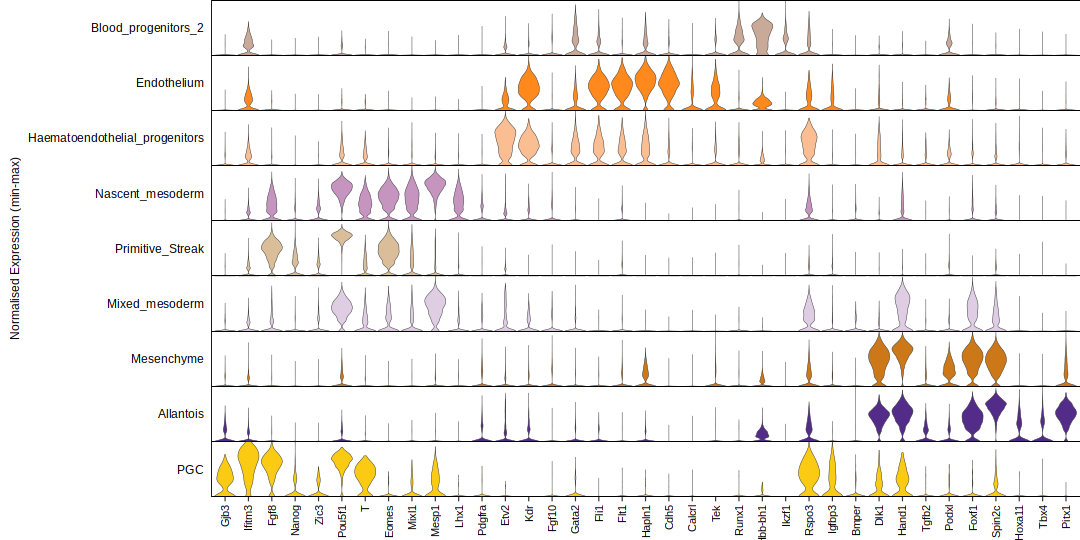

In [15]:
expr_plot = expr %>%
    .[, gene := factor(gene, levels = features)] %>%
    .[celltype %in% opts$celltype_order] %>%
    .[, celltype := factor(celltype, levels = opts$celltype_order)] %>%
    .[, expression_minmax_pruned := ifelse(expression_minmax > quantile(expression_minmax, 0.95), quantile(expression_minmax, 0.95),expression_minmax),
          by = c('celltype', 'gene')]
                                        
options(repr.plot.width=9, repr.plot.height=4.5)

p2 = ggplot(expr_plot, aes(gene, expression_minmax, fill = celltype)) + 
    geom_violin(scale = 'width', linewidth = 0.1) +
    scale_fill_manual(values = opts$celltype.colors) + 
    scale_y_continuous(expand = c(0,0)) + 
    facet_grid(celltype~., switch = 'y') +
    ylab('Normalised Expression (min-max)') + 
    theme_bw() + 
    theme(axis.text.x = element_text(color = 'black',
                                     angle = 90, 
                                     hjust = 1,
                                     vjust = 0.5, size=6),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank(),
            axis.title.x = element_blank(),
            strip.background = element_blank(),
            strip.text.y.left = element_text(angle = 0, hjust = 1, color= 'black', size=7),
            panel.spacing = unit(0,'lines'),
            panel.grid = element_blank(),
            legend.position = 'none',
            axis.title.y = element_text(size = 7, vjust = -2),
            panel.background = element_rect(color = "white", fill = NA, linewidth = 0.01),
            panel.border = element_rect(color = "black", fill = NA, linewidth = 0.2),
            plot.margin = margin(0,0,0,0),
            axis.line.y = element_blank(),
            axis.line.x = element_line(color = 'black', linewidth = 0.1),
            axis.ticks = element_line(linewidth=0.25),
)
p2